In [1]:
import tqdm
import mrcfile
import numpy as np
import matplotlib.pyplot as plt

from ttsim3d.models import Simulator, SimulatorConfig
from torch_so3 import get_uniform_euler_angles

from panther_em.decomposition import PolarProjectionDecomposer, DecompositionResult

## Load in volume to take projections from

In [2]:
!wget -nc https://files.rcsb.org/download/pdb_00007myi.cif

File ‘pdb_00007myi.cif’ already there; not retrieving.



In [3]:
pdb_path = "pdb_00007myi.cif"

In [4]:
# Instantiate the configuration object
sim_conf = SimulatorConfig(
    voltage=300.0,  # in keV
    apply_dose_weighting=True,
    dose_start=0.0,  # in e-/A^2
    dose_end=15.0,   # in e-/A^2
    upsampling=-1,   # auto
)

# Instantiate the simulator
sim = Simulator(
    pdb_filepath=pdb_path,
    pixel_spacing=0.8,  # Angstroms
    volume_shape=(256, 256, 256),
    b_factor_scaling=1.0,
    additional_b_factor=0.0,
    simulator_config=sim_conf,
)

In [5]:
# Run the simulation
volume = sim.run()
print(type(volume))
print(volume.shape)

/home/mgiammar/git_repositories/Panther-EM/.venv/lib/python3.12/site-packages/ttsim3d/simulate3d.py:50: FutureWarning: This function is deprecated and will be removed in a future version. Please use torch_ctf.calculate_relativistic_electron_wavelength instead.
  wavelength_m = calculate_relativistic_electron_wavelength(beam_energy_ev)


<class 'torch.Tensor'>
torch.Size([256, 256, 256])


In [6]:
volume = volume.numpy()

## Define the out-of-plane orientations

Using `torch-so3` to approximate points over SO(3) space, except all in-plane angles are set to zero.

In [7]:
angles = get_uniform_euler_angles(psi_step=360.0, theta_step=2.5)
angles.shape

phi_angles = angles[:, 0].numpy()
theta_angles = angles[:, 1].numpy()

In [ ]:
radial_components = 128
angular_components = 720

decomposer = PolarProjectionDecomposer(
    volume=volume,
    phi_values=phi_angles,
    theta_values=theta_angles,
    device="cuda",
    num_radial_components=radial_components,
    num_angular_components=angular_components,
)

result = decomposer.do_decomposition()

decomp freq blocks: 100%|██████████| 360/360 [00:02<00:00, 138.08it/s]


In [9]:
result

DecompositionResult(num_orientations=6602, num_angular_components=360, num_radial_components=182, k_max=360, created_at='2026-01-26T14:58:10.569414')

## Visualize results

In [10]:
k_idx = 17
eig_idx = 12

polar_feature = decomposer.construct_polar_feature(k_idx=k_idx, eig_idx=eig_idx)
cartesian_feature = decomposer.construct_cartesian_feature(k_idx=k_idx, eig_idx=eig_idx)


# Plot the real and imaginary parts of the polar on a polar mpl plot
fig, ax = plt.subplots(1, 2, figsize=(8, 6))

im0 = ax[0].imshow(np.real(polar_feature), cmap="coolwarm")
ax[0].set_title("Real Part")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(np.imag(polar_feature), cmap="coolwarm")
ax[1].set_title("Imaginary Part")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

# Plot the reconstructed cartesian feature
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

im0 = ax[0].imshow(np.real(cartesian_feature), cmap="coolwarm")
ax[0].set_title("Real Part")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(np.imag(cartesian_feature), cmap="coolwarm")
ax[1].set_title("Imaginary Part")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

/home/mgiammar/git_repositories/Panther-EM/.venv/lib/python3.12/site-packages/torch/_inductor/lowering.py:1988: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(


AssertionError: expected size 182==182, stride 1==182 at dim=0
Error in op: torch.ops.prims.device_put.default
This error most often comes from a incorrect fake (aka meta) kernel for a custom op.
Use torch.library.opcheck to test your custom op.
See https://pytorch.org/docs/stable/library.html#torch.library.opcheck

In [ ]:
result.left_singular_vectors.shape

(360, 6602, 182)

In [ ]:
proj = decomposer.reconstruct_projection(orientation_idx=0)
proj.shape

(256, 256)

In [ ]:
# Reconstruct and plot the first N projections
N = 256

projections = []
for i in tqdm.tqdm(range(N)):
    proj = decomposer.reconstruct_projection(orientation_idx=i)
    projections.append(proj)

  2%|▏         | 4/256 [00:19<20:37,  4.91s/it]


KeyboardInterrupt: 

IndexError: list index out of range

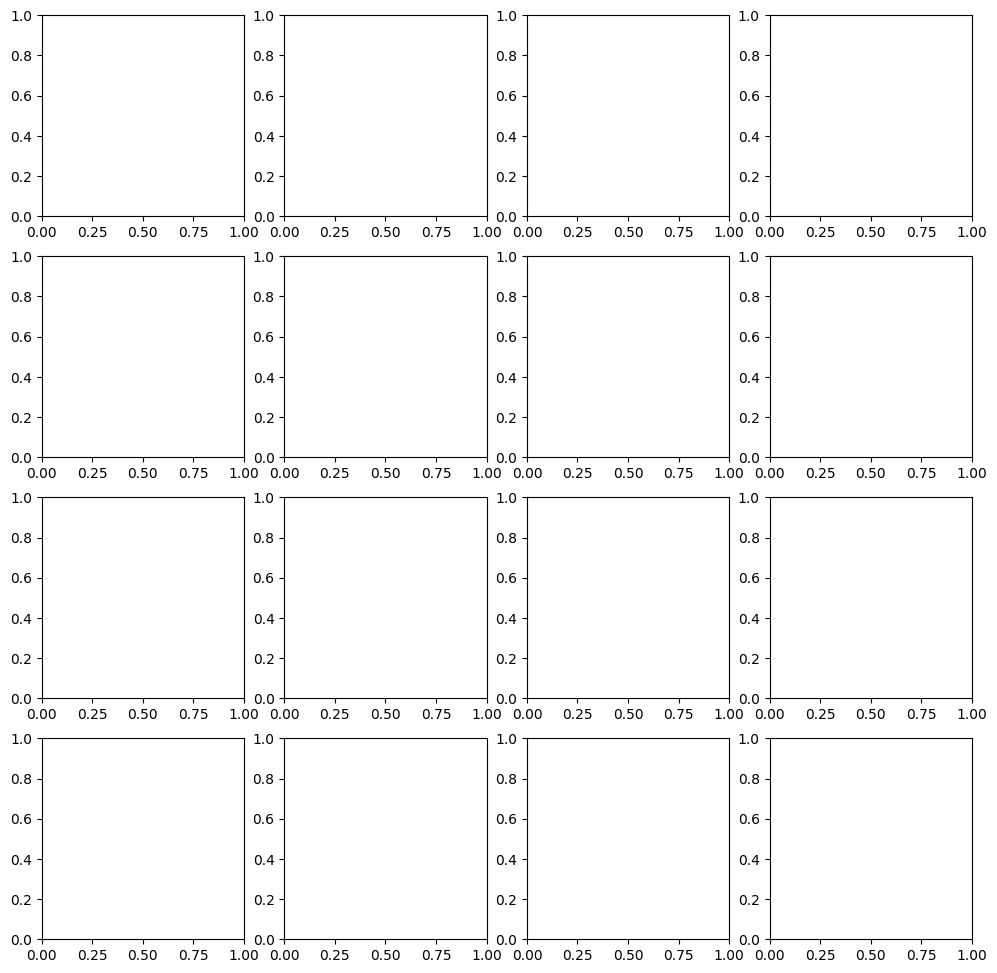

In [ ]:
# starting index
start_idx = 32

fig, ax = plt.subplots(4, 4, figsize=(12, 12))
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        idx = start_idx + i * ax.shape[1] + j
        ax[i, j].imshow(projections[idx].real, cmap="magma")
        ax[i, j].set_title(f"Reconstruction {idx}")

plt.tight_layout()
plt.show()

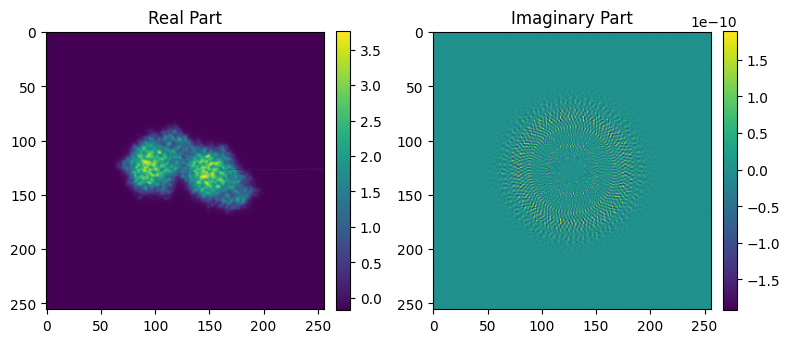

In [ ]:
# Display real and imaginary parts of the projection (with colorbars)
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

im0 = ax[0].imshow(np.real(proj))
ax[0].set_title("Real Part")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(np.imag(proj))
ax[1].set_title("Imaginary Part")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()